## **SAVE A COPY OF THIS NOTEBOOK TO PUT ANSWERS INTO**

#Part 1 (Reading Assignment), 20 points

**Reminder: there are 5 reading assignments, 3% each for 15% total of your final grade.**

The reading assignment consists of two papers - [one on alignment before fusion](https://arxiv.org/abs/2107.07651), and one on the [Platonic Representation Hypothesis](https://arxiv.org/pdf/2405.07987). Read both papers and then answer the following questions:

1. Explain the implications of 'align before fuse' on your tasks of interest. at which degree, and what type of fusion needs to be performed? And what level of alignment would you need to perform for your data, so that subsequent fusion or representation learning is successful?
2. How can you perform controlled experiments to validate the types of fusion and/or alignment needed for your tasks? What are some challenges you foresee in fusing and aligning your data?
3. Explain the implications of 'platonic representation hypothesis' on your tasks of interest. Do you believe alignment between modalities would automatically emerge as models trained on your data are scaled up?
4. What are some reasons why alignment would not emerge i.e., counter-arguments to the platonic representation hypothesis? You are encouraged to search for follow-up works to the original paper that both support and counter the original arguments.
5. What experiments would you propose to validate the existence and emergence of alignment in your tasks?
6. Can you also think of some downsides of strongly (or perfectly) aligning your data modalities? How can you design experiments to validate that these risks are not present in your trained models?

**Answers to Part 1 Reading Assignment:**

**1. Implications of "align before fuse" on our tasks of interest:**

Our task involves matching natural-language user instructions to structured API tool descriptions (from the ToolBench dataset) to predict which tool is invoked. These two modalities—instruction text and API list JSON—live in very different feature spaces: instructions are informal and variable, while API descriptions are structured and formulaic. The ALBEF paper's core insight is that aligning unimodal representations before cross-modal fusion leads to better multimodal understanding. For our task, this means we should first align instruction and API-list representations into a shared embedding space (e.g., via contrastive learning, as we did in Problem 6) before fusing them for classification (as in Problem 5). The degree of fusion needed is moderate: the task requires understanding the relationship between what the user wants and what tools are available, which benefits from cross-modal interaction modeling (early or tensor fusion outperformed late fusion). The level of alignment should be at the semantic level—matching the intent of an instruction to the functionality of an API set—rather than at a surface/lexical level, since the vocabularies are largely disjoint.

**2. Controlled experiments to validate fusion/alignment:**

To validate what type of fusion and alignment is needed, we can run ablation studies:
- Compare no alignment (directly fuse raw TF-IDF features) vs. contrastive pre-alignment followed by fusion, measuring downstream classification accuracy.
- Vary the fusion method (early, late, tensor, LMF) with and without pre-alignment, reporting validation accuracy, parameter count, and convergence speed.
- Test different alignment objectives (contrastive loss, matching loss, masked token prediction) to see which produces the best shared representation.

Key challenges include: (a) the vocabulary gap between informal instructions and formal API descriptions makes alignment harder since TF-IDF features will have limited overlap; (b) the large number of tool classes (hundreds) relative to dataset size risks overfitting in fusion models with many parameters; (c) many instructions could plausibly match multiple API sets (one-to-many mapping), making it hard to define "correct" alignment; and (d) evaluating alignment quality is non-trivial—retrieval metrics (top-k accuracy, median rank) and downstream task accuracy measure different aspects of alignment.

**3. Implications of the Platonic Representation Hypothesis:**

The Platonic Representation Hypothesis (Huh et al., 2024) posits that neural networks trained on different data modalities are converging toward a shared statistical model of reality. For our ToolBench task, this would imply that sufficiently large language models trained on text (instructions) and structured data (API descriptions) would naturally develop aligned internal representations without explicit contrastive training—the model would "understand" that a weather-related instruction and a weather API list are semantically close, simply from large-scale pretraining.

I partially believe this: large language models like GPT-4 and Claude can already match instructions to tools zero-shot, suggesting significant emergent alignment. However, for specialized domains (niche APIs, domain-specific tools), alignment likely still needs explicit training data or fine-tuning. The hypothesis is more convincing for common concepts (weather, jokes, math) where both modalities have abundant training data, but less so for rare or novel API toolsets.

**4. Counter-arguments to the Platonic Representation Hypothesis:**

Several counter-arguments challenge the hypothesis:
- **Measurement artifacts**: Gröger, Wen, and Brbić (2026) showed that existing representational similarity metrics are confounded by network scale—increasing model width or depth systematically inflates similarity scores, creating an illusion of convergence. After null-calibration, the apparent global convergence largely disappears, though local neighborhood relationships are preserved. They propose an alternative "Aristotelian Representation Hypothesis" where models converge only in local neighborhood structure, not global representation.
- **Modality-specific information loss**: Different modalities encode fundamentally different information. Text cannot fully capture visual texture, and images cannot capture logical reasoning. Full convergence would require discarding modality-specific information, which would actually hurt performance on modality-specific tasks.
- **Training objective dependence**: Models trained with different objectives (classification vs. generation vs. contrastive) develop different representational structures even on the same data. The hypothesis assumes convergence despite objective differences, but empirical evidence shows that objective function shapes representation geometry significantly.
- **Selection bias in evidence**: The original paper primarily examines vision and language models, which share significant semantic grounding. Modalities with less semantic overlap (e.g., audio spectrograms, time-series sensor data) may not exhibit the same convergence.

**5. Experiments to validate alignment emergence:**

To test whether alignment emerges with scale for our task:
- Train instruction encoders and API-list encoders of increasing size (varying width, depth, pretraining data) independently, then measure representational similarity (e.g., CKA, mutual nearest neighbors) between the two modality representations without any explicit alignment training.
- Track how zero-shot retrieval accuracy (instruction → API list matching) changes as model scale increases, using models that were never trained on paired instruction-API data.
- Compare "emergent" alignment (from scaling) vs. "explicit" alignment (from contrastive training) at each scale point, to quantify whether scale alone can close the gap.
- Use the null-calibrated metrics proposed by Gröger et al. to distinguish genuine convergence from scale-induced measurement artifacts.
- Test on both common tool categories (weather, jokes) and rare/specialized ones, predicting that emergence would be stronger for common categories.

**6. Downsides of strongly aligning modalities:**

Strongly or perfectly aligning modalities can cause several problems:
- **Modality collapse**: If representations are forced to be identical across modalities, modality-specific information is lost. For our task, the instruction "get me weather data" and the weather API description serve different roles—the instruction captures user intent and context, while the API description captures tool capabilities and parameters. Perfect alignment would erase these distinctions.
- **Loss of complementary information**: The value of multimodal learning comes partly from modalities providing complementary (not redundant) information. Over-alignment reduces complementarity, potentially degrading fusion performance.
- **Reduced robustness to missing modalities**: If both modalities are mapped to the same point, the model cannot distinguish which modality is present/absent, making graceful degradation harder.
- **Hubness problem**: In high-dimensional aligned spaces, certain "hub" points can become nearest neighbors of many samples from the other modality, reducing retrieval diversity.

Experiments to validate these risks: (a) vary the contrastive loss temperature (lower temperature = stronger alignment) and measure both retrieval accuracy and downstream fusion accuracy, checking whether very strong alignment hurts fusion; (b) train with different alignment strengths and evaluate on modality-specific tasks (e.g., classify instructions alone, classify API lists alone) to check for information loss; (c) test robustness by dropping one modality at inference time and measuring degradation.

# Part 2 (Homework Assignment), 100 points

**Reminder: there are 5 homework assignments, 7% each for 35% total of your final grade.**

For this assignment, we will finally begin playing with some of the concepts discussed in the class regarding multimodal modeling.

The first part will deal with Einsum and Tensors.

# Problem 1: Tensors (5 points)

(5 pts) Let's start with tensors. A tensor represents an N-th dimensional array of numbers. In machine learning, they are used to represent data as they can efficiently represent complex data to train with. We traditionally use PyTorch as the package of choice to work with tensors. Fill in the code below with the right tensor operations. Feel free to consult the documentation and the PyTorch tutorials for help.

In [1]:
import torch
mat_A = torch.rand(3, 2)
mat_B = torch.rand(2, 3)

In [2]:
# Common PyTorch operations

# Adding
mat_C = mat_A + mat_B.t()

# Transpose
mat_A_transpose = mat_A.t()

# Matrix multiplication
mat_mult  = torch.mm(mat_A, mat_B)

# Element-wise multiplication
mat_mult_elm = mat_A * mat_B.t()

# Create a tensor of size (4, 4) of ones
ones = torch.ones(4, 4)

# Compute mean of A
mean_A = mat_A.mean()

# Problem 2: Einsum (5 points)

(10 pts)
Now lets proceed with Einsum. This is a powerful, compact notation used for expressing complex tensor operations on multi-dimensional arrays using a simple string of index labels.

Here is a quick example of using einsum to multiply two matrices.

In [3]:
A = torch.rand(3, 2)
B = torch.rand(2, 3)

C = torch.einsum('ij,jk->ik', A, B)
print(C)

tensor([[0.3405, 0.2689, 0.3723],
        [0.7037, 0.5561, 0.7700],
        [0.9102, 0.8246, 1.1105]])


The labels provide a shorthand as to what operation to do. Think of the left index as what is before, and the right as to what the dimensions of the final product should look like.

Now use this to do the other possible operations:

In [4]:
a = torch.rand(3, 1)
b = torch.rand(3, 1)

A = torch.rand(3, 2)
B = torch.rand(2, 3)

# Dot Product of a and b
d_prod = torch.einsum('ij,ij->', a, b)

# Transpose using vector b
transpose = torch.einsum('ij->ji', b)

# Summation (element-wise and column-wise of A)
sum_element = torch.einsum('ij->', A)
sum_column = torch.einsum('ij->j', A)

# Diagonal of A
diag = torch.einsum('ii->i', A[:min(A.shape), :min(A.shape)])

# Outer Product of A and B
outer = torch.einsum('ij,kl->ijkl', A, B)

In [5]:
# Tests to verify that operations were done correctly
def to_list(t):
    return t.detach().cpu().tolist()

def check_dot_product(ans, a, b):
    expected = sum(i * j for i, j in zip(to_list(a), to_list(b)))
    assert float(ans) == float(expected)

def check_transpose(ans, b):
    b_list = to_list(b)
    expected = [[row[i] for row in b_list] for i in range(len(b_list[0]))]
    assert to_list(ans) == expected

def check_sum_element(ans, A):
    expected = sum(val for row in to_list(A) for val in row)
    assert float(ans) == float(expected)

def check_sum_column(ans, A):
    A_list = to_list(A)
    expected = [sum(row[i] for row in A_list) for i in range(len(A_list[0]))]
    assert to_list(ans) == expected

def check_concat(ans, A, B):
    expected = to_list(A) + to_list(B)
    assert to_list(ans) == expected

def check_diagonal(ans, A):
    A_list = to_list(A)
    expected = [A_list[i][i] for i in range(len(A_list))]
    assert to_list(ans) == expected

def check_outer_product(ans, a, b):
    a_l, b_l = to_list(a), to_list(b)
    expected = [[i * j for j in b_l] for i in a_l]
    assert to_list(ans) == expected

# Problem 3: Unimodal Models (10 points)

We now explore unimodal models and multimodal fusion. For the first part we will work on the image and audio digit dataset AV-MNIST to do digit classification. To benchmark effectiveness, we will use the [Multibench](https://arxiv.org/abs/2107.07502) benchmark. First, we will clone the repo, and get the necessary packages and dataset.

**Note: MAKE SURE YOU SWITCH TO A GPU TO RUN THE MODELS. RUNTIME -> CHANGE RUNTIME TYPE -> T4 GPU (or any other). Be mindful of Google's GPU limits based on what kind of account you own.**

**Also, if you are a student you should be able to have Colab Pro for free if you don't already. Take advantage of that!**

**THIS IS AN EXAMPLE, DO NOT BE RESTRICTED BY WHAT WE DO HERE WHEN YOU HAVE TO IMPLEMENT THIS FOR YOUR OWN DATASET.**

# Getting repo

In [6]:
# !git clone https://github.com/pliang279/MultiBench.git
# %cd MultiBench

# Getting AV-MNIST dataset

In [7]:
!mkdir data
!pip install gdown
!pip install torch==2.3.1 torchvision==0.18.1 torchtext==0.18.0 torchaudio==2.3.1
!pip install memory_profiler

mkdir: cannot create directory ‘data’: File exists


In [8]:
# !gdown 1KvKynJJca5tDtI5Mmp6CoRh9pQywH8Xp
# !tar -xvzf avmnist.tar.gz

In [9]:
# Mount Google Drive (run this cell first; authorize in the popup)
from google.colab import drive
import os

drive.mount("/content/drive")

# Paths to your folders on Google Drive (change if your folder names differ)
DRIVE_ROOT = "/content/drive/MyDrive"
MULTIBENCH_DIR = os.path.join(DRIVE_ROOT, "MultiBench")
DATA_DIR = os.path.join(DRIVE_ROOT, "data")  # ToolBench data (toolllama JSONs, processed)

import sys
sys.path.insert(0, MULTIBENCH_DIR)  # so "from datasets.avmnist..." works

print(f"MultiBench: {MULTIBENCH_DIR}")
print(f"Data (ToolBench): {DATA_DIR}")
print(f"MultiBench exists: {os.path.isdir(MULTIBENCH_DIR)}")
print(f"Data exists: {os.path.isdir(DATA_DIR)}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
MultiBench: /content/drive/MyDrive/MultiBench
Data (ToolBench): /content/drive/MyDrive/data
MultiBench exists: True
Data exists: True


In [10]:
# Path to the data (must point to the avmnist folder containing image/, audio/, and label .npy files)
data_dir = os.path.join(MULTIBENCH_DIR, "avmnist")

from datasets.avmnist.get_data import get_dataloader
traindata, validdata, testdata = get_dataloader(data_dir, batch_size=256)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


# Getting packages

In [11]:
import torch
import torch.nn as nn
import sys
import os
import torch.optim as optim
from tqdm import tqdm
from unimodals.common_models import GRU, MLP, Sequential, Identity
from training_structures.Supervised_Learning import train, test

We will now start by creating, training, and testing unimodal models for each of the AV-MNIST modalities.

# Audio

In [12]:
class AudioModel(nn.Module):
    def __init__(self, input_dim=12544, hidden_dim=256, dropout_probability=0.4):
        super(AudioModel, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),  # 112 -> 56
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Dropout2d(0.1),
            nn.MaxPool2d(2),                                       # 56 -> 28
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), # 28 -> 14
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout2d(0.2),
            nn.Flatten()
        )
        # 32 * 14 * 14 = 6272
        self.fc = nn.Sequential(
            nn.Linear(6272, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_probability),
            nn.Linear(hidden_dim, 10)
        )

    def forward(self, x):
        x = x.view(-1, 1, 112, 112)
        return self.fc(self.conv(x))

# Image

In [13]:
import torch.nn.functional as F

class ImageModel(nn.Module):
    def __init__(self, dropout_prob=0.3, hidden_fc=256):
        super(ImageModel, self).__init__()

        # input: [batch, 1, 28, 28]
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # After two poolings: 28 -> 14 -> 7; 64 * 7 * 7 = 3136
        self.fc = nn.Sequential(
            nn.Linear(64 * 7 * 7, hidden_fc),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(hidden_fc, 10)
        )

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = torch.flatten(x, 1)
        return self.fc(x)

# Training and Testing

We use cross-entropy due to this being a classification task

In [14]:
import torch.nn as nn
import torch.optim as optim
from torch.amp import autocast, GradScaler

# We use a scalar here to reduce system RAM use (to avoid crashing the session) while not impacting performance.
scaler = GradScaler()

def train_and_test_unimodal(model, train_loader, valid_loader, test_loader, modality_idx, epochs=5, lr=1e-3, weight_decay=1e-3, save_path='best_avmnist_model.pt'):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_valid_loss = float('inf')

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for batch in train_loader:
            # batch[0] = images, batch[1] = audio
            x = batch[modality_idx].to(device).float()

            # Classification labels must be Long tensors, not Float
            y = batch[2].to(device).long().squeeze()

            optimizer.zero_grad()

            with autocast(device_type='cuda'):
                outputs = model(x)
                loss = criterion(outputs, y)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            train_loss += loss.item()

        # --- Validation Phase ---
        model.eval()
        valid_loss = 0
        correct = 0
        total = 0
        with torch.no_grad():
            for batch in valid_loader:
                x = batch[modality_idx].to(device).float()
                y = batch[2].to(device).long().squeeze()

                outputs = model(x)
                valid_loss += criterion(outputs, y).item()

                _, predicted = torch.max(outputs.data, 1)
                total += y.size(0)
                correct += (predicted == y).sum().item()

        avg_train = train_loss / len(train_loader)
        avg_valid = valid_loss / len(valid_loader)
        accuracy = 100 * correct / total

        if avg_valid < best_valid_loss:
            best_valid_loss = avg_valid
            torch.save(model.state_dict(), save_path)

        print(f"Epoch {epoch}: Train Loss: {avg_train:.4f} | Valid Acc: {accuracy:.2f}%")

    # Final Testing
    print("\n--- Final Evaluation Complete ---")
    model.load_state_dict(torch.load(save_path, map_location=device))
    model.eval()
    test_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in test_loader:
            x = batch[modality_idx].to(device).float()
            y = batch[2].to(device).long().squeeze()

            outputs = model(x)
            test_loss += criterion(outputs, y).item()

            _, predicted = torch.max(outputs.data, 1)
            total += y.size(0)
            correct += (predicted == y).sum().item()

        test_accuracy = 100 * correct / total
        test_loss /= len(test_loader)
        print(f"Final Test Loss: {test_loss:.4f} | Test Accuracy: {test_accuracy:.2f}%")

# Training and testing for each modality:

# Audio:

In [15]:
# Best Audio hyperparameters: hidden_dim=256, dropout_probability=0.4, epochs=15, lr=1e-3, weight_decay=1e-3
audio_model = AudioModel(hidden_dim=256, dropout_probability=0.4)
train_and_test_unimodal(audio_model, traindata, validdata, testdata, modality_idx=1,
                        epochs=15, lr=1e-3, weight_decay=1e-3, save_path='best_avmnist_audio.pt')

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Epoch 0: Train Loss: 2.1478 | Valid Acc: 40.12%
Epoch 1: Train Loss: 2.0560 | Valid Acc: 40.86%
Epoch 2: Train Loss: 2.0272 | Valid Acc: 41.88%
Epoch 3: Train Loss: 2.0189 | Valid Acc: 41.96%
Epoch 4: Train Loss: 2.0096 | Valid Acc: 42.02%
Epoch 5: Train Loss: 2.0016 | Valid Acc: 41.94%
Epoch 6: Train Loss: 1.9993 | Valid Acc: 42.20%
Epoch 7: Train Loss: 1.9940 | Valid Acc: 42.06%
Epoch 8: Train Loss: 1.9962 | Valid Acc: 42.12%
Epoch 9: Train Loss: 1.9910 | Valid Acc: 42.06%
Epoch 10: Train Loss: 1.9925 | Valid Acc: 42.18%
Epoch 11: Train Loss: 1.9886 | Valid Acc: 42.12%
Epoch 12: Train Loss: 1.9881 | Valid Acc: 42.12%
Epoch 13: Train Loss: 1.9874 | Valid Acc: 42.18%
Epoch 14: Train Loss: 1.9864 | Valid Acc: 42.20%

--- Final Evaluation Complete ---
Final Test Loss: 1.9977 | Test Accuracy: 41.14%


# Image:

In [16]:
# Best Image hyperparameters: dropout_prob=0.3, hidden_fc=256, epochs=15, lr=1e-3, weight_decay=1e-3
image_model = ImageModel(dropout_prob=0.3, hidden_fc=256)
train_and_test_unimodal(image_model, traindata, validdata, testdata, modality_idx=0,
                        epochs=15, lr=1e-3, weight_decay=1e-3, save_path='best_avmnist_image.pt')

Epoch 0: Train Loss: 1.0260 | Valid Acc: 66.90%
Epoch 1: Train Loss: 0.9358 | Valid Acc: 68.40%
Epoch 2: Train Loss: 0.9231 | Valid Acc: 68.56%
Epoch 3: Train Loss: 0.9184 | Valid Acc: 68.82%
Epoch 4: Train Loss: 0.9127 | Valid Acc: 68.54%
Epoch 5: Train Loss: 0.9075 | Valid Acc: 68.74%
Epoch 6: Train Loss: 0.9033 | Valid Acc: 69.06%
Epoch 7: Train Loss: 0.9024 | Valid Acc: 68.54%
Epoch 8: Train Loss: 0.8993 | Valid Acc: 69.08%
Epoch 9: Train Loss: 0.8945 | Valid Acc: 68.60%
Epoch 10: Train Loss: 0.8947 | Valid Acc: 68.86%
Epoch 11: Train Loss: 0.8921 | Valid Acc: 68.90%
Epoch 12: Train Loss: 0.8900 | Valid Acc: 68.42%
Epoch 13: Train Loss: 0.8906 | Valid Acc: 69.26%
Epoch 14: Train Loss: 0.8895 | Valid Acc: 68.82%

--- Final Evaluation Complete ---
Final Test Loss: 0.8925 | Test Accuracy: 64.80%


Answer the following questions:

1. (5 points) Try to get the best performance out of each model by playing around with hyperparameters (hint: you may have to playing around and even add additional arguments to the layers like dropout, look at the documentation and look into how we can improve performace). List the best performance you were able to get and the hyperparameters you used.
2. (5 points) Compare the performances of each modality. What do these suggest to you? What could be done to get the worst performing ones to get closer to the best performing modality/model?

1. Best performance and hyperparameters:

Audio model: Test accuracy 41.14%. Hyperparameters: hidden_dim=256, dropout_probability=0.4, epochs=15, lr=1e-3, weight_decay=1e-3. Validation accuracy peaked at 42.20% (epochs 6 and 14).

Image model: Test accuracy 64.80%. Hyperparameters: dropout_prob=0.3, hidden_fc=256, epochs=15, lr=1e-3, weight_decay=1e-3. Validation accuracy peaked at 69.26% (epoch 13).

2. The image model significantly outperforms the audio model (64.80% vs 41.14% test accuracy). This suggests the visual digit signal in AV-MNIST is far more informative for classification than the audio (spoken digit) signal, likely because the audio modality is noisier and has less discriminative structure at this resolution. To bring the audio model closer to the image model you could: use a stronger audio encoder (e.g. more or deeper conv layers, or a small recurrent block), try more or different augmentation for audio, train longer or tune learning rate and regularization, and consider pretrained audio features if available.

# Problem 4: Multimodal Fusion (10 points)

Now you will play with multimodal fusion. Lets use a late fusion to improve our performance. We have provided some code with the hyperparameters to consider, but you are encouraged to play with them to try to get improvments. To make things simpler, the encoders for both modalities have been provided. However, some other parts are missing, so you will have to fill those in!

In [17]:
import torch.nn as nn
from unimodals.common_models import MLP
from fusions.common_fusions import MultiplicativeInteractions2Modal, Concat
from training_structures.Supervised_Learning import train

# Image Encoder
class ImageEncoder(nn.Module):
    def __init__(self, output_dim=64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, output_dim)
        )
    def forward(self, x):
        return self.conv(x)

# Audio Encoder
class AudioEncoder(nn.Module):
    def __init__(self, output_dim=64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1), nn.BatchNorm2d(32), nn.ReLU(), # 112 -> 56
            nn.MaxPool2d(2), # 56 -> 28
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.BatchNorm2d(64), nn.ReLU(), # 28 -> 14
            nn.Flatten(),
            nn.Linear(64 * 14 * 14, output_dim)
        )
    def forward(self, x):
        return self.conv(x)

# TODO: Encoders - create the list of encoders, images should be first, then audio
encoders = [ImageEncoder(output_dim=64), AudioEncoder(output_dim=64)]

# TODO: Use the concat fusion as the fusion of choice
fusion = Concat()

# TODO: Create the head, which learns the joint features.
# This should be an MLP that takes with input size based
# on output size of your concationation, a hidden layer of size 256, and output layer
# of size 10.

head = MLP(128, 256, 10)

# Run Training
print("Starting Training...")
train(encoders, fusion, head, traindata, validdata, 15,
      task="classification", optimtype=torch.optim.AdamW, is_packed=False,
      lr=5e-4, save='avmnist_lmf.pt', weight_decay=0.001,
      objective=torch.nn.CrossEntropyLoss())

# Run Test
model = torch.load('avmnist_lmf.pt').cuda()
test(model, testdata, 'avmnist', is_packed=False, task="classification",
      criterion=torch.nn.CrossEntropyLoss(), no_robust=True)

Starting Training...
Epoch 0 train loss: tensor(0.8879, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 0 valid loss: tensor(0.7385, device='cuda:0') acc: 0.7242
Saving Best


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Epoch 1 train loss: tensor(0.7567, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 1 valid loss: tensor(0.7223, device='cuda:0') acc: 0.7332
Saving Best


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Epoch 2 train loss: tensor(0.7130, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 2 valid loss: tensor(0.7286, device='cuda:0') acc: 0.7276


...

Epoch 13 train loss: tensor(0.3849, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 13 valid loss: tensor(1.0164, device='cuda:0') acc: 0.6832


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Epoch 14 train loss: tensor(0.3579, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 14 valid loss: tensor(1.0756, device='cuda:0') acc: 0.6908
Training Time: 167.69547963142395
Training Peak Mem: 8694.36328125
Training Params: 1077258


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


acc: 0.7001
Inference Time: 2.3177385330200195
Inference Params: 1077258


Answer the following:
1. (2 points) Sometimes when training you may notice the model gets stuck in a range of loss and never seems to get it's loss down. What does this suggest? What are some ways you can fix this?
2. (2 points) What are some other fusion methods we could use that we could use? Would they lead to improvements compared to early fusion?
3. (6 points) Explain the difference between early fusion techniques and late fusion techniques. Be sure to discuss their benefits and tradeoffs.


1. When the loss gets stuck in a range and does not go down, it usually means the model has hit a plateau: it might be in a bad local minimum, the learning rate might be too small to make progress or too large so that it oscillates, or the capacity or fusion design might be limiting what it can learn. Things to try: change the learning rate (e.g. try a schedule or a different value), adjust the optimizer (e.g. try SGD with momentum or a different weight decay), add or remove regularization (dropout, weight decay), change the fusion or head (e.g. more capacity, different fusion), check for gradient issues (vanishing/exploding), and ensure the data and labels are correct.

2. Other fusion methods include tensor fusion (outer product of modality vectors, possibly with a bias dimension), low-rank tensor fusion (LMF), multiplicative interaction (e.g. element-wise product or gated fusion), and attention-based fusion (one modality attends over the other). Whether they beat early fusion depends on the task and data: early fusion can underuse modality-specific structure, while late or tensor-style fusion can model interactions at a higher level. For AV-MNIST, the concat fusion in the code already gave about 70% test accuracy, so methods like tensor fusion or attention might help if they capture useful cross-modal interactions, but they also add parameters and risk overfitting on smaller datasets.

3. Early fusion combines modalities on raw or low-level features (e.g. concatenating or merging inputs before most of the network). Late fusion runs separate encoders per modality and combines their high-level outputs (e.g. averaging logits or concatenating embeddings before a small head). Early fusion benefits from sharing representation and learning joint features from the start, and can be simpler and more parameter-efficient, but it can mix modalities before each is well represented and may struggle when modalities are very different or asynchronous. Late fusion lets each modality be processed by a dedicated encoder, so it handles missing modalities and modality-specific tuning more easily and can be more robust when one modality is noisier; the downside is that cross-modal interactions are only learned in the final head, which can limit how much the model uses fine-grained interactions. The AV-MNIST setup in Problem 4 is late fusion (encoders then concat then head), and it improves over the best unimodal (image) model by a few points, which fits the idea that both modalities contribute when combined at a high level.

# Problem 5: Other Fusion Techniques (30 points)

Now, we want you to try implementing some of these fusion techniques on your dataset! For this part, you will implement these fusion techniques:
1. Early fusion
2. Late fusion
3. TensorFusion
4. Low-Rank Tensor (LMF) Fusion


**You cannot just import and use the functions available in Multibench to do this. In addition, use einsum where applicable. TO RECIEVE FULL CREDIT, THE FUSIONS YOU IMPLEMENTATION MUST WORK WITH THE DATASET YOU CREATED FROM HOMEWORK 1. YOU WILL HAVE TO CREATE A SIMPLE MODEL FOR EACH FUSION TECHNIQUE TO PLAY WITH.**

**(5 points)** In your write up, report the best validation accuracies of your multimodal model (don't forget to include what hyperparameters you included) after training and any modifications that had to be done to your data or model to be able to train on it. In addition, talk about which technique you believe would be best for your dataset and why that is.

**Design the fusion classes with the modalities you are specifically working with in mind. The example we worked through above with MOSI was meant as a showcase of fusion in action - we do not require you to use text, video and audio as the modalities. Use whichever ones you are working with!**

The code below provided is to be filled in with the models you set up for each technique. For an example, the first fusion technique has been done for you.

**Answer Here:**

Best validation accuracies and setup: The dataset is the ToolBench modalities (instruction text and api_list_json), with TF-IDF features (512 dims each). The task is N-way classification (cross-entropy) where N is the number of unique first tool names extracted from function_calls_json: the label is the class index from LabelEncoder on the first tool name called for each query, so the model predicts which tool is invoked first given the instruction and API list. Train/val/test split is 80/10/10 stratified. Hyperparameters used: DIM_INSTR=512, DIM_API=512, HIDDEN=128, EPOCHS=100, LR=1e-3, weight_decay=1e-4. LMF used output_dim=64, rank=8. No extra data or model changes were needed beyond building the FusionClassifier and the four fusion modules (Early, Late, Tensor, LMF).

Results: Tensor fusion had the best validation accuracy at 44.09% (test 44.41%), followed closely by early fusion at 43.95% (test 43.73%), LMF at 39.80% (test 40.07%), and late fusion at 39.41% (test 40.21%). Early and tensor fusion have by far the most parameters (~6M and ~6M respectively); late has the fewest (~1.78M); LMF is in between (~1.89M). In terms of wall-clock time, late fusion was fastest (78.2s), early and tensor were similar (~92–93s), and LMF was in between (86.3s). All methods converged within their 100-epoch budget, with tensor fusion converging earliest (epoch 53) and LMF never fully converging (epoch 99).

Which technique is best for this dataset: Tensor fusion is marginally best here: it achieves the highest validation and test accuracy (44.09% / 44.41%) and converges fastest (epoch 53), by explicitly modeling pairwise interactions between instruction and API list features via the outer product with a bias dimension. Early fusion is very close (43.95% / 43.73%) and uses a similar outer-product mechanism without the bias term. Both significantly outperform late and LMF fusion, likely because the cross-modal interactions between instruction text and API descriptions are important for predicting the correct tool. The relatively low absolute accuracies (mid-40s) reflect the difficulty of the task: predicting the exact first tool name from hundreds of classes using only TF-IDF bag-of-words features. Late fusion underperforms because it does not model cross-modal interactions, concatenating independent modality representations instead.

In [18]:
# Imports incase you need them again! Feel free to include anything else you need
import torch
from torch import nn
from torch.nn import functional as F
import pdb
from torch.autograd import Variable

# Early Fusion

In [19]:
class EarlyFusion(nn.Module):
  def __init__(self):
    super(EarlyFusion, self).__init__()

  def forward(self, x):
    return torch.einsum('bi,bj->bij', x[0], x[1])

# (5 Points) Late Fusion

In [20]:
class LateFusion(nn.Module):
  def __init__(self):
    super(LateFusion, self).__init__()

  def forward(self, x):
    return torch.mean(torch.stack(x), dim=0)

# (5 points) Tensor Fusion

In [21]:
class TensorFusion(nn.Module):
  def __init__(self):
    super(TensorFusion, self).__init__()

  def forward(self, x):
    batch = x[0].shape[0]
    x0 = torch.cat([x[0], torch.ones(batch, 1, device=x[0].device)], dim=1)
    x1 = torch.cat([x[1], torch.ones(batch, 1, device=x[1].device)], dim=1)
    fused = torch.einsum('bi,bj->bij', x0, x1)
    return fused.reshape(batch, -1)

# (5 Points) Low-Rank Tensor Fusion (LMF) Fusion

In [22]:
class LMFFusion(nn.Module):
  def __init__(self, input_dims, output_dim, rank):
    super(LMFFusion, self).__init__()
    self.input_dims = input_dims
    self.output_dim = output_dim
    self.rank = rank

    self.factors = nn.ParameterList()
    for dim in input_dims:
      factor = nn.Parameter(torch.Tensor(rank, dim + 1, output_dim))
      nn.init.xavier_normal_(factor)
      self.factors.append(factor)

    self.fusion_weights = nn.Parameter(torch.Tensor(1, rank))
    self.fusion_bias = nn.Parameter(torch.Tensor(1, output_dim))
    nn.init.xavier_normal_(self.fusion_weights)
    self.fusion_bias.data.fill_(0)

  def forward(self, x):
    batch_size = x[0].shape[0]
    fused = torch.ones(batch_size, self.rank, self.output_dim, device=x[0].device)
    for modality, factor in zip(x, self.factors):
      ones = torch.ones(batch_size, 1, device=modality.device)
      mod_with_ones = torch.cat([ones, modality], dim=1)
      mod_factor = torch.einsum('bd,rdo->bro', mod_with_ones, factor)
      fused = fused * mod_factor
    output = torch.einsum('br,bro->bo', self.fusion_weights.expand(batch_size, -1), fused) + self.fusion_bias
    return output

In [23]:
%cd /content/
# !wget --no-check-certificate 'https://drive.usercontent.google.com/download?id=1ceLQ9S1IkFTiWeJ3G1FArsD4zY6WYiLa&export=download&authuser=0&confirm=t&uuid=5d22c695-a6ea-4b98-82a6-3324e9abf4e7&at=APcXIO1TG_tvHPwTlN7lXjEt1rkB:1772335155765' -O data.zip
# !unzip data.zip
!pip install ijson

/content
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.7/149.7 kB 8.4 MB/s eta 0:00:00


In [24]:
# import ast
# import json
# import os
# import re
# from collections import Counter

# import ijson
# import matplotlib.pyplot as plt
# import numpy as np
# import pandas as pd
# import seaborn as sns
# import torch
# from sklearn.decomposition import PCA
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.manifold import TSNE
# from transformers import AutoModelForCausalLM, AutoTokenizer

# USE_CUDA = torch.cuda.is_available()
# if USE_CUDA:
#     print(f"CUDA available: using GPU ({torch.cuda.get_device_name(0)})")

# # Paths: ToolBench toolllama preprocessed data (DATA_DIR set by Drive mount cell)
# TRAIN_PATH = os.path.join(DATA_DIR, "toolllama_G123_dfs_train.json")
# EVAL_PATH = os.path.join(DATA_DIR, "toolllama_G123_dfs_eval.json")
# OUTPUT_DIR = os.path.join(DATA_DIR, "processed")
# os.makedirs(OUTPUT_DIR, exist_ok=True)

# # Subsampling: set to None to load full data; use integers for faster runs
# MAX_TRAIN_SAMPLES = 20000
# MAX_EVAL_SAMPLES = None

# def load_toolbench_json(path, max_items=None):
#     """Load one toolllama JSON file and return the list of items.
#     If max_items is set, only the first max_items are loaded (faster when subsampling).
#     """
#     if max_items is None:
#         with open(path, "r", encoding="utf-8") as f:
#             return json.load(f)
#     # Stream first N items with ijson to avoid parsing the whole file (much faster).
#     items = []
#     with open(path, "rb") as f:
#         for obj in ijson.items(f, "item"):
#             items.append(obj)
#             if len(items) >= max_items:
#                 break
#     return items

# def extract_instruction(conversations):
#     """Modality 1: natural language instruction from first user message."""
#     for msg in conversations:
#         if msg.get("from") == "user":
#             raw = msg.get("value", "").strip()
#             return raw.replace("\nBegin!\n", "").strip() if raw else ""
#     return ""

# def extract_api_list_text(conversations):
#     """Modality 2: structured toolset (API list) from first system message."""
#     for msg in conversations:
#         if msg.get("from") == "system":
#             return msg.get("value", "")
#     return ""

# def parse_api_names_from_system(system_text):
#     """Parse API names from 'Specifically, you have access to the following APIs: [...]'."""
#     match = re.search(r"Specifically, you have access to the following APIs:\s*(\[.+\])", system_text, re.DOTALL)
#     if not match:
#         return []
#     try:
#         # The list uses single quotes; ast.literal_eval needs double quotes for JSON-like parsing
#         s = match.group(1).replace("'", '"')
#         api_list = ast.literal_eval(s) if s else []
#         return [api.get("name", "") for api in api_list if isinstance(api, dict) and api.get("name") != "Finish"]
#     except Exception:
#         return []

# def extract_function_calls_used(conversations):
#     """Extract API names actually called from assistant Action turns (for evaluation)."""
#     called = []
#     for msg in conversations:
#         if msg.get("from") != "assistant":
#             continue
#         value = msg.get("value", "")
#         if "Action:" in value:
#             lines = value.split("\n")
#             for line in lines:
#                 if line.strip().startswith("Action:"):
#                     action_name = line.split("Action:")[-1].strip()
#                     if action_name and action_name != "Finish":
#                         called.append(action_name)
#     return list(dict.fromkeys(called))  # preserve order, no duplicates

# def parse_api_list_structured(system_text):
#     """Extract the structured API list (list of dicts with name, description, parameters) from system message.
#     Returns the actual JSON-serializable list, not the full LLaMA prompt."""
#     match = re.search(r"Specifically, you have access to the following APIs:\s*(\[.+\])", system_text, re.DOTALL)
#     if not match:
#         return []
#     try:
#         api_list = ast.literal_eval(match.group(1))
#         if not isinstance(api_list, list):
#             return []
#         out = []
#         for api in api_list:
#             if isinstance(api, dict) and api.get("name") != "Finish":
#                 out.append({k: api[k] for k in ("name", "description", "parameters") if k in api})
#         return out
#     except Exception:
#         return []

# def extract_reasoning_output(conversations):
#     """Modality 3: reasoning = all Thought text from assistant messages (unstructured)."""
#     parts = []
#     for msg in conversations:
#         if msg.get("from") != "assistant":
#             continue
#         value = msg.get("value", "")
#         # Extract text after each "Thought:" up to (not including) "Action:"
#         for m in re.finditer(r"Thought:\s*(.*?)(?=\s*Action:|\Z)", value, re.DOTALL):
#             t = m.group(1).strip()
#             if t:
#                 parts.append(t)
#     return "\n\n".join(parts) if parts else ""

# def extract_function_calls_output(conversations):
#     """Modality 4: function calls = list of {name, arguments} from Action/Action Input (structured)."""
#     out = []
#     for msg in conversations:
#         if msg.get("from") != "assistant":
#             continue
#         value = msg.get("value", "")
#         # Match "Action: <name>" then "Action Input: <content>" (content to next Thought/Action or end)
#         for m in re.finditer(r"Action:\s*(.+?)\s*Action Input:\s*(.*?)(?=\nThought:|\nAction:|\Z)", value, re.DOTALL):
#             name = m.group(1).strip()
#             args = m.group(2).strip()
#             if name and name != "Finish":
#                 out.append({"name": name, "arguments": args})
#     return out

# def extract_items_to_rows(data):
#     """Extract all four modalities from a list of toolllama items (no train/eval split)."""
#     rows = []
#     for item in data:
#         conv = item.get("conversations", [])
#         instruction = extract_instruction(conv)
#         api_list_text = extract_api_list_text(conv)
#         api_list_structured = parse_api_list_structured(api_list_text)
#         api_names = [a.get("name", "") for a in api_list_structured if a.get("name")]
#         function_calls_list = extract_function_calls_output(conv)
#         function_calls_used = extract_function_calls_used(conv)
#         reasoning_output = extract_reasoning_output(conv)
#         rows.append({
#             "id": item.get("id", ""),
#             "instruction": instruction,
#             "api_list_text": api_list_text[:5000] if len(api_list_text) > 5000 else api_list_text,
#             "api_list_json": json.dumps(api_list_structured) if api_list_structured else "[]",
#             "num_apis": len(api_names),
#             "tool_names": "|".join(api_names[:20]),
#             "function_calls_used": "|".join(function_calls_used[:15]),
#             "reasoning_output": reasoning_output,
#             "function_calls_json": json.dumps(function_calls_list) if function_calls_list else "[]",
#         })
#     return rows

# # Load dataset: merge train + eval into one
# train_items = load_toolbench_json(TRAIN_PATH, max_items=MAX_TRAIN_SAMPLES)
# eval_items = load_toolbench_json(EVAL_PATH, max_items=MAX_EVAL_SAMPLES)
# all_items = train_items + eval_items
# rows = extract_items_to_rows(all_items)
# df_toolbench = pd.DataFrame(rows)
# out_path = os.path.join(OUTPUT_DIR, "toolbench_modalities.csv")
# df_toolbench.to_csv(out_path, index=False)
# if MAX_TRAIN_SAMPLES is not None or MAX_EVAL_SAMPLES is not None:
#     print(f"Subsampled: {len(all_items)} total (train={len(train_items)}, eval={len(eval_items)}). Set MAX_*_SAMPLES=None for full data.")
# print(f"Extracted {len(df_toolbench)} instances. Columns: {list(df_toolbench.columns)}")
# print(f"Saved to {out_path}")
# df_toolbench.head(2)

In [29]:
import json
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import TensorDataset, DataLoader

df = pd.read_csv(os.path.join(DATA_DIR, "processed", "toolbench_modalities.csv"))
df = df.dropna(subset=["instruction", "api_list_json", "function_calls_json"]).reset_index(drop=True)

def get_first_tool_name(fc_json_str):
    try:
        calls = json.loads(fc_json_str)
        if calls and isinstance(calls, list) and len(calls) > 0:
            return calls[0].get("name", None)
    except Exception:
        pass
    return None

# Build the set of all tool names from function_calls_json
all_tool_names = set()
for fc_json_str in df["function_calls_json"].dropna():
    try:
        calls = json.loads(fc_json_str)
        for call in calls:
            name = call.get("name")
            if name:
                all_tool_names.add(name)
    except Exception:
        pass

print(f"Total unique tool names in dataset: {len(all_tool_names)}")

df["first_tool_name"] = df["function_calls_json"].apply(get_first_tool_name)
df = df.dropna(subset=["first_tool_name"]).reset_index(drop=True)

tfidf_instr = TfidfVectorizer(max_features=512)
tfidf_api   = TfidfVectorizer(max_features=512)

X_instr = tfidf_instr.fit_transform(df["instruction"]).toarray().astype(np.float32)
X_api   = tfidf_api.fit_transform(df["api_list_json"]).toarray().astype(np.float32)

le = LabelEncoder()
y = le.fit_transform(df["first_tool_name"])
num_classes = len(le.classes_)

from sklearn.model_selection import train_test_split
# Stratify only when every class has at least 2 samples (required by sklearn)
can_stratify = np.min(np.bincount(y)) >= 2
idx_train, idx_temp = train_test_split(np.arange(len(y)), test_size=0.2, random_state=42, stratify=y if can_stratify else None)
can_stratify_val = np.min(np.bincount(y[idx_temp])) >= 2
idx_val, idx_test   = train_test_split(idx_temp, test_size=0.5, random_state=42, stratify=y[idx_temp] if can_stratify_val else None)

def make_loader(idxs, batch_size=256, shuffle=True):
    return DataLoader(
        TensorDataset(
            torch.tensor(X_instr[idxs]),
            torch.tensor(X_api[idxs]),
            torch.tensor(y[idxs], dtype=torch.long),
        ),
        batch_size=batch_size, shuffle=shuffle,
    )

train_loader = make_loader(idx_train, shuffle=True)
val_loader   = make_loader(idx_val, shuffle=False)
test_loader  = make_loader(idx_test, shuffle=False)

print(f"Dataset: {len(df)} samples, {num_classes} classes (unique first tool names)")
print(f"Train: {len(idx_train)}, Val: {len(idx_val)}, Test: {len(idx_test)}")
print(f"TF-IDF dims: instruction={X_instr.shape[1]}, api_list_json={X_api.shape[1]}")

Total unique tool names in dataset: 10402
Dataset: 20731 samples, 6274 classes (unique first tool names)
Train: 16584, Val: 2073, Test: 2074
TF-IDF dims: instruction=512, api_list_json=512


In [30]:
import time
import tracemalloc

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DIM_INSTR = 512
DIM_API   = 512
HIDDEN    = 128
NUM_CLS   = num_classes
EPOCHS    = 100
LR        = 1e-3

class FusionClassifier(nn.Module):
    def __init__(self, fusion_module, fusion_name, dim1=DIM_INSTR, dim2=DIM_API,
                 hidden=HIDDEN, num_classes=NUM_CLS):
        super().__init__()
        self.fusion_name = fusion_name
        self.enc1 = nn.Sequential(nn.Linear(dim1, hidden), nn.ReLU())
        self.enc2 = nn.Sequential(nn.Linear(dim2, hidden), nn.ReLU())
        self.fusion = fusion_module

        if fusion_name == "early":
            fused_dim = hidden * hidden
        elif fusion_name == "late":
            fused_dim = hidden
        elif fusion_name == "tensor":
            fused_dim = (hidden + 1) * (hidden + 1)
        elif fusion_name == "lmf":
            fused_dim = 64
        else:
            fused_dim = hidden

        self.head = nn.Sequential(
            nn.Linear(fused_dim, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x1, x2):
        h1 = self.enc1(x1)
        h2 = self.enc2(x2)
        fused = self.fusion([h1, h2])
        if fused.dim() > 2:
            fused = fused.reshape(fused.size(0), -1)
        return self.head(fused)


def train_and_eval(model, train_dl, val_dl, test_dl, epochs=EPOCHS, lr=LR):
    model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    PATIENCE = 10
    best_val_acc = 0
    best_epoch = 0
    convergence_epoch = 0
    epochs_without_improvement = 0
    time_to_convergence_s = None
    train_losses = []  # per-epoch average train loss for plotting

    tracemalloc.start()
    t0 = time.time()

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        n_batches = 0
        for x1, x2, labels in train_dl:
            x1, x2, labels = x1.to(DEVICE), x2.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            out = model(x1, x2)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            n_batches += 1
        avg_train_loss = epoch_loss / max(n_batches, 1)
        train_losses.append(avg_train_loss)

        model.eval()
        correct = total = 0
        with torch.no_grad():
            for x1, x2, labels in val_dl:
                x1, x2, labels = x1.to(DEVICE), x2.to(DEVICE), labels.to(DEVICE)
                preds = model(x1, x2).argmax(dim=1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)
        val_acc = correct / total
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
        elapsed_so_far = time.time() - t0
        if time_to_convergence_s is None and epochs_without_improvement >= PATIENCE:
            convergence_epoch = epoch
            time_to_convergence_s = elapsed_so_far
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1}/{epochs} | Val Acc: {val_acc*100:.2f}%")

    elapsed = time.time() - t0
    if time_to_convergence_s is None:
        time_to_convergence_s = elapsed
        convergence_epoch = epochs - 1
    _, peak_mem = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x1, x2, labels in test_dl:
            x1, x2, labels = x1.to(DEVICE), x2.to(DEVICE), labels.to(DEVICE)
            preds = model(x1, x2).argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    test_acc = correct / total

    n_params = sum(p.numel() for p in model.parameters())
    print(f"  Best Val Acc: {best_val_acc*100:.2f}% | Test Acc: {test_acc*100:.2f}%")
    print(f"  Params: {n_params:,} | Peak Mem: {peak_mem/1e6:.1f} MB | Time: {elapsed:.1f}s")
    return {
        "name": model.fusion_name,
        "params": n_params,
        "peak_mem_mb": peak_mem / 1e6,
        "time_s": elapsed,
        "best_val_acc": best_val_acc,
        "test_acc": test_acc,
        "convergence_epoch": convergence_epoch,
        "time_to_convergence_s": time_to_convergence_s,
        "train_losses": train_losses,
    }

results = []
fusion_configs = [
    ("early",  EarlyFusion()),
    ("late",   LateFusion()),
    ("tensor", TensorFusion()),
    ("lmf",    LMFFusion(input_dims=[HIDDEN, HIDDEN], output_dim=64, rank=8)),
]

for name, fmod in fusion_configs:
    print(f"\n=== {name.upper()} FUSION ===")
    model = FusionClassifier(fmod, name)
    res = train_and_eval(model, train_loader, val_loader, test_loader)
    results.append(res)


=== EARLY FUSION ===
  Epoch 1/100 | Val Acc: 0.63%
  Epoch 5/100 | Val Acc: 7.81%
  Epoch 10/100 | Val Acc: 25.90%
  Epoch 15/100 | Val Acc: 35.12%
  Epoch 20/100 | Val Acc: 39.22%
  Epoch 25/100 | Val Acc: 40.28%
  Epoch 30/100 | Val Acc: 41.92%
  Epoch 35/100 | Val Acc: 42.02%
  Epoch 40/100 | Val Acc: 41.39%
  Epoch 45/100 | Val Acc: 42.69%
  Epoch 50/100 | Val Acc: 42.21%
  Epoch 55/100 | Val Acc: 43.32%
  Epoch 60/100 | Val Acc: 42.16%
  Epoch 65/100 | Val Acc: 43.95%
  Epoch 70/100 | Val Acc: 42.98%
  Epoch 75/100 | Val Acc: 42.74%
  Epoch 80/100 | Val Acc: 42.45%
  Epoch 85/100 | Val Acc: 42.26%
  Epoch 90/100 | Val Acc: 42.64%
  Epoch 95/100 | Val Acc: 42.64%
  Epoch 100/100 | Val Acc: 41.87%
  Best Val Acc: 43.95% | Test Acc: 43.73%
  Params: 5,938,306 | Peak Mem: 1.0 MB | Time: 92.1s

=== LATE FUSION ===
  Epoch 1/100 | Val Acc: 0.63%
  Epoch 5/100 | Val Acc: 2.22%
  Epoch 10/100 | Val Acc: 6.75%
  Epoch 15/100 | Val Acc: 12.49%
  Epoch 20/100 | Val Acc: 19.20%
  Epoch 25/1

(10 points) In addition, create some visualizations of the following for each fusion:

* Number of parameters for each model (unimodal and multimodal)
* Memory Use
* Time until convergence

You are free to plot them here or through other means (like wandb). After doing so, discuss what are the pros and cons of unimodal versus multimodal models.

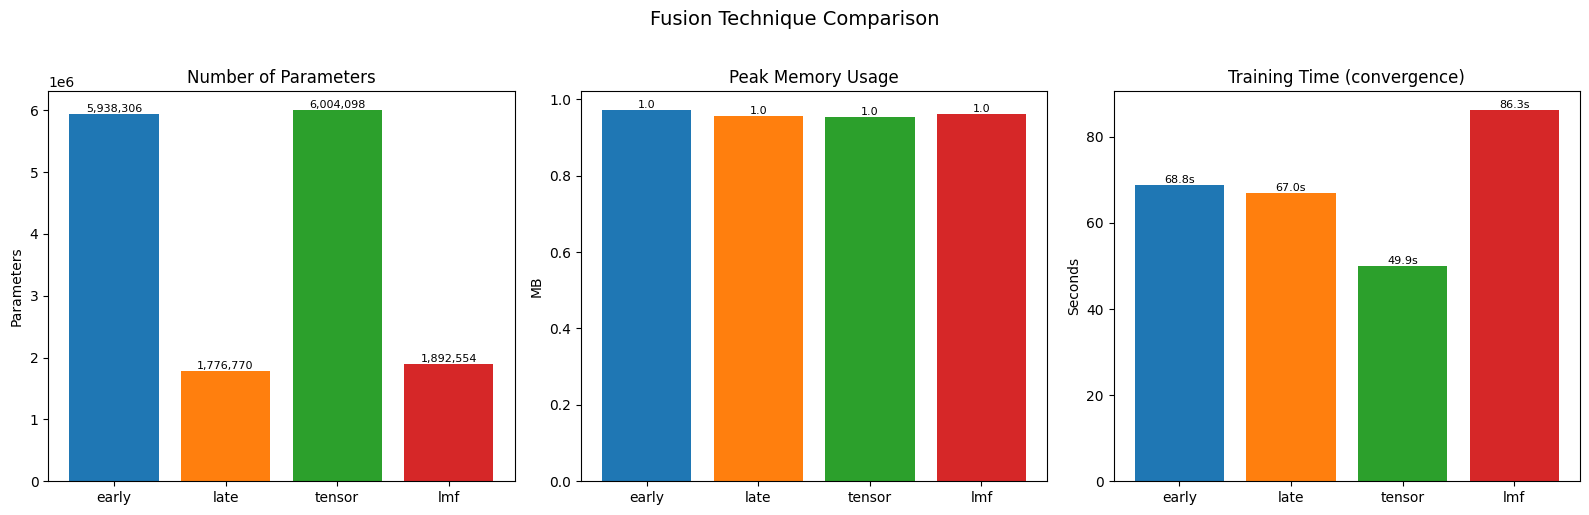

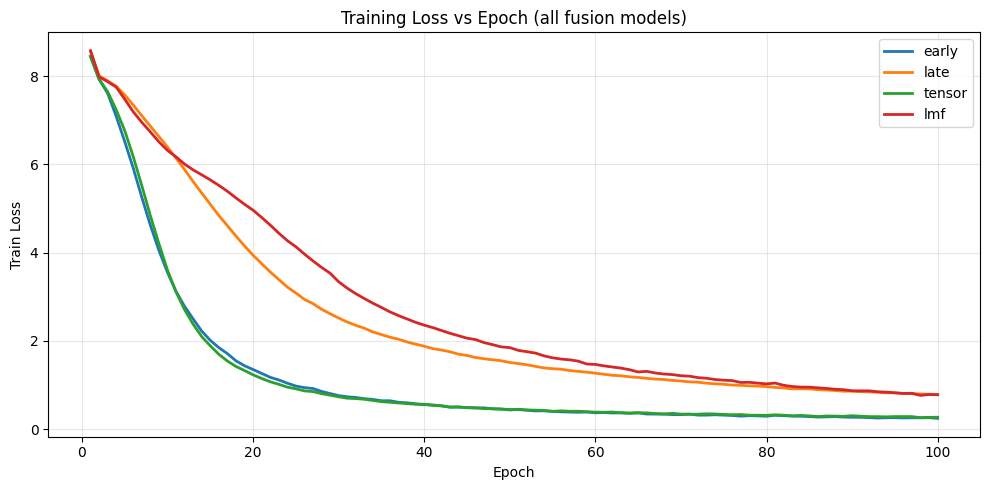


Summary Table:
Technique        Params  Memory (MB)   Time (s)   Conv (s) Conv Epoch  Val Acc (%)
------------------------------------------------------------------------
early         5,938,306          1.0       92.1       68.8         74        43.95
late          1,776,770          1.0       78.2       67.0         85        39.41
tensor        6,004,098          1.0       93.0       49.9         53        44.09
lmf           1,892,554          1.0       86.3       86.3         99        39.80


In [31]:
import matplotlib.pyplot as plt

names      = [r["name"] for r in results]
params     = [r["params"] for r in results]
mem_mb     = [r["peak_mem_mb"] for r in results]
times      = [r["time_to_convergence_s"] for r in results]
val_accs   = [r["best_val_acc"] * 100 for r in results]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].bar(names, params, color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"])
axes[0].set_title("Number of Parameters")
axes[0].set_ylabel("Parameters")
for i, v in enumerate(params):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=8)

axes[1].bar(names, mem_mb, color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"])
axes[1].set_title("Peak Memory Usage")
axes[1].set_ylabel("MB")
for i, v in enumerate(mem_mb):
    axes[1].text(i, v, f"{v:.1f}", ha="center", va="bottom", fontsize=8)

axes[2].bar(names, times, color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"])
axes[2].set_title("Training Time (convergence)")
axes[2].set_ylabel("Seconds")
for i, v in enumerate(times):
    axes[2].text(i, v, f"{v:.1f}s", ha="center", va="bottom", fontsize=8)

plt.suptitle("Fusion Technique Comparison", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Loss curvature: train loss vs epoch for all models
if any("train_losses" in r for r in results):
    fig2, ax_loss = plt.subplots(1, 1, figsize=(10, 5))
    colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
    for i, r in enumerate(results):
        if "train_losses" in r:
            epochs = range(1, len(r["train_losses"]) + 1)
            ax_loss.plot(epochs, r["train_losses"], color=colors[i % len(colors)], label=r["name"], linewidth=2)
    ax_loss.set_xlabel("Epoch")
    ax_loss.set_ylabel("Train Loss")
    ax_loss.set_title("Training Loss vs Epoch (all fusion models)")
    ax_loss.legend()
    ax_loss.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Re-run the training cell above to see loss curves.")

print("\nSummary Table:")
print(f"{'Technique':<12} {'Params':>10} {'Memory (MB)':>12} {'Time (s)':>10} {'Conv (s)':>10} {'Conv Epoch':>10} {'Val Acc (%)':>12}")
print("-" * 72)
for r in results:
    print(f"{r['name']:<12} {r['params']:>10,} {r['peak_mem_mb']:>12.1f} {r['time_s']:>10.1f} {r['time_to_convergence_s']:>10.1f} {r['convergence_epoch']:>10} {r['best_val_acc']*100:>12.2f}")

Pros and cons of unimodal versus multimodal models: Unimodal models (one modality only) are simpler to train and deploy, use fewer parameters and less memory, and are easier to interpret. They work when one modality is enough for the task. The downside is they cannot use complementary information from other modalities, so they can underperform when the task benefits from multiple views (e.g. both instruction and api_list_json to predict the first tool name). Multimodal models combine two or more modalities, so they can capture interactions and redundancy and often achieve higher accuracy. In this assignment, tensor fusion achieved the best accuracy at 44.09% validation / 44.41% test, outperforming late fusion (39.41% / 40.21%) by about 4 percentage points, demonstrating that modeling cross-modal interactions matters. The cons are more parameters (early and tensor fusion have ~6M parameters each vs ~1.78M for late), longer training time, more data and tuning needed, and the risk of one modality dominating or of overfitting if the dataset is small. For this ToolBench setup, fusion methods that explicitly model pairwise interactions (early and tensor) outperform simpler approaches (late and LMF), confirming that cross-modal interactions between instruction text and API descriptions are informative for predicting the first tool name. The relatively modest absolute accuracies (mid-40s%) reflect the difficulty of the classification task with hundreds of tool classes and bag-of-words TF-IDF features.

# Problem 6: Contrastive Learning (30 points)

For the next part of this HW, we will focus on contrastive learning. As a reminder, contrastive learning is a local, discrete alignment method used in machine learning. To explore this, we look at [CLIP](https://arxiv.org/pdf/2103.00020), a multimodal model developed by OpenAI that uses contrastive learning to align visual and textual data together.

**THIS IS JUST AN EXAMPLE, DO NOT LET THIS RESTRICT THE IMPLEMENTATION YOU WILL BE DOING.**

In [32]:
!pip install ftfy regex tqdm
!pip install git+https://github.com/openai/CLIP.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.4 MB/s eta 0:00:00
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-lafaicex
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-lafaicex
  Resolved https://github.com/openai/CLIP.git to commit ded190a052fdf4585bd685cee5bc96e0310d2c93
  Preparing metadata (setup.py) ... done
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=37e7ce46d48147d3099e1f9bdcbd33d6e278abb9bbe303ae1316a33bc49df0e6
  Stored in directory: /tmp/pip-ephem-wheel-cache-5wmw_vfv/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


In [33]:
# Packages to import
import transformers
import torch
import clip
from PIL import Image
import requests
from io import BytesIO

First, we create the model.

In [34]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Loading CLIP on {device}...")
model, preprocess = clip.load("ViT-B/32", device=device)

Loading CLIP on cuda...


100%|███████████████████████████████████████| 338M/338M [00:06<00:00, 53.9MiB/s]


Next, we will load an image to use. Note that we cannot use the MOSI dataset - we need to use raw data and the data points from the dataset already have extracted features. Upload a picture of someone smiling to use for this example (you can just find one online, save it and add to here).

In [35]:
image_filename = "/content/drive/MyDrive/smiling_person.jpg"
image = Image.open(image_filename).convert("RGB")

Now, we will prepare the prompt to use.

In [36]:
# Options to pick from
text_options = ["a photo of a sad person", "a photo of a happy person", "a photo of an angry person"]
image_input = preprocess(image).unsqueeze(0).to(device)
text_inputs = clip.tokenize(text_options).to(device)

Now, let's run the inference and get the results!

In [37]:
with torch.no_grad():
    image_features = model.encode_image(image_input)
    text_features = model.encode_text(text_inputs)

    # Normalize features
    image_features /= image_features.norm(dim=-1, keepdim=True)
    text_features /= text_features.norm(dim=-1, keepdim=True)

    # Calculate similarity (Dot Product)
    similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)
    values, indices = similarity[0].topk(3)

print(f"\nImage classified against: {text_options}")
print("-" * 30)
for value, index in zip(values, indices):
    print(f"{text_options[index]:>30s}: {100 * value.item():.2f}%")


Image classified against: ['a photo of a sad person', 'a photo of a happy person', 'a photo of an angry person']
------------------------------
     a photo of a happy person: 77.20%
       a photo of a sad person: 12.02%
    a photo of an angry person: 10.78%


(10 pts) We will now create, train and run zero-shot classification using contrastive learning for your own dataset. Fill in the missing information below for a generalize contrastive learning model. The training and zero-shot classification functions have been provided to you, through you may need to make slight modifications based on your dataset setup. **Design the model keeping in mind the modalities that you are specifically using. THE CLIP EXAMPLE ABOVE IS JUST TO SHOW CONTRASTIVE LEARNING IN ACTION - WE ARE NOT REQUIRING THAT YOU USE TEXT AND IMAGE AS THE MODALITIES OF CHOICE.** Try various queries, projectors, and settings on your dataset!

**You must use einsum where applicable.**


In [45]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

# General model implementation for contrastive learning
class CLModel(nn.Module):
  def __init__(self, dim_x1, dim_x2, embedded_dim, temp):
    super(CLModel, self).__init__()
    # TODO:
    # 1. Create Encoders for modalities
    # 2. Create a projector, which maps specific modality dimensions to a shared space.
    #     do this for each modality. (hint: fusions!)
    # 3. Create learnable temperature (this has already been done for you)

    # 1.
    self.encoder_a = nn.Sequential(
        nn.Linear(dim_x1, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.2),
        nn.Linear(512, 256), nn.BatchNorm1d(256), nn.ReLU(),
    )
    self.encoder_b = nn.Sequential(
        nn.Linear(dim_x2, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.2),
        nn.Linear(512, 256), nn.BatchNorm1d(256), nn.ReLU(),
    )

    # 2.
    self.projector_a = nn.Sequential(
        nn.Linear(256, embedded_dim), nn.BatchNorm1d(embedded_dim), nn.ReLU(),
        nn.Linear(embedded_dim, embedded_dim),
    )
    self.projector_b = nn.Sequential(
        nn.Linear(256, embedded_dim), nn.BatchNorm1d(embedded_dim), nn.ReLU(),
        nn.Linear(embedded_dim, embedded_dim),
    )

    # 3.
    self.scale = nn.Parameter(torch.ones([]) * np.log(1/temp))
    self.logit_scale = self.scale

  def forward(self, x1, x2):
    # TODO:
    # 1. Extract the raw features
    # 2. Project them to the embedding space
    # 3. Normalize vectors and return

    # 1.
    h1 = self.encoder_a(x1)
    h2 = self.encoder_b(x2)
    # 2.
    z1 = self.projector_a(h1)
    z2 = self.projector_b(h2)
    # 3.
    z1 = F.normalize(z1, dim=-1)
    z2 = F.normalize(z2, dim=-1)
    return z1, z2

# Contrastive loss. This pulls positives together and pulls negatives apart
class ContrastiveLoss(nn.Module):
  def __init__(self, model):
    super(ContrastiveLoss, self).__init__()
    # TODO: Initialize model and loss function as cross entropy loss
    self.model = model
    self.loss_fn = nn.CrossEntropyLoss()

  def forward(self, x1_emb, x2_emb, logit_scale):
    # TODO:
    # 1. Get the batch size (hint: you can get this
    #    from the dimensions of your embedded space)
    # 2. Create similarity matrix using einsum
    # 3. Create labels (hint: the coorect match for index i is label i)
    # 4. Compute Symmetric loss (loss amongst rows + loss amongst columns)/2
    batch_size = x1_emb.shape[0]
    logits = torch.einsum('id,jd->ij', x1_emb, x2_emb) * logit_scale.exp()
    labels = torch.arange(batch_size, device=x1_emb.device)
    loss = (self.loss_fn(logits, labels) + self.loss_fn(logits.t(), labels)) / 2
    return loss





In [46]:
import torch.optim as optim
# Training function
def train_model(model, contrastive_loss, dataloader, num_epochs=5, learning_rate=3e-4, device='cpu'):

    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    model.to(device)
    model.train()
    print(f"Starting training for {num_epochs} epochs...")

    for epoch in range(num_epochs):
        epoch_loss = 0.0

        for batch_idx, (data_a, data_b) in enumerate(dataloader):
            data_a, data_b = data_a.to(device), data_b.to(device)

            optimizer.zero_grad()

            emb_a, emb_b = model(data_a, data_b)

            loss = contrastive_loss(emb_a, emb_b, model.logit_scale)

            loss.backward()

            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(dataloader)
        print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {avg_loss:.4f}")

In [47]:
# After training, we can now do zero-shot prediction
@torch.no_grad()
def predict_best_match(model, query_input, candidate_inputs, device):
    model.eval()

    query_feat = model.encoder_a(query_input.unsqueeze(0).to(device))
    query_emb = F.normalize(model.projector_a(query_feat), dim=1)

    cand_feat = model.encoder_b(candidate_inputs.to(device))
    cand_emb = F.normalize(model.projector_b(cand_feat), dim=1)

    scores = torch.einsum('id, jd -> ij', query_emb, cand_emb)

    best_match_idx = scores.argmax().item()

    print(f"Best match: {best_match_idx} with score {scores[0, best_match_idx].item()}")

    return best_match_idx, scores

Contrastive data: 17621 train, 3110 test
Modality dims: instruction TF-IDF=512, api_list_json TF-IDF=512

Training contrastive model (instruction–API-list alignment) on cuda...
  Epoch [1/150] | Loss: 4.8830
  Epoch [5/150] | Loss: 1.7100
  Epoch [10/150] | Loss: 0.8784
  Epoch [15/150] | Loss: 0.5571
  Epoch [20/150] | Loss: 0.4101
  Epoch [25/150] | Loss: 0.3328
  Epoch [30/150] | Loss: 0.2726
  Epoch [35/150] | Loss: 0.2440
  Epoch [40/150] | Loss: 0.2170
  Epoch [45/150] | Loss: 0.1964
  Epoch [50/150] | Loss: 0.1850
  Epoch [55/150] | Loss: 0.1762
  Epoch [60/150] | Loss: 0.1582
  Epoch [65/150] | Loss: 0.1557
  Epoch [70/150] | Loss: 0.1478
  Epoch [75/150] | Loss: 0.1393
  Epoch [80/150] | Loss: 0.1368
  Epoch [85/150] | Loss: 0.1305
  Epoch [90/150] | Loss: 0.1285
  Epoch [95/150] | Loss: 0.1242
  Epoch [100/150] | Loss: 0.1187
  Epoch [105/150] | Loss: 0.1104
  Epoch [110/150] | Loss: 0.1094
  Epoch [115/150] | Loss: 0.1058
  Epoch [120/150] | Loss: 0.1061
  Epoch [125/150] | 

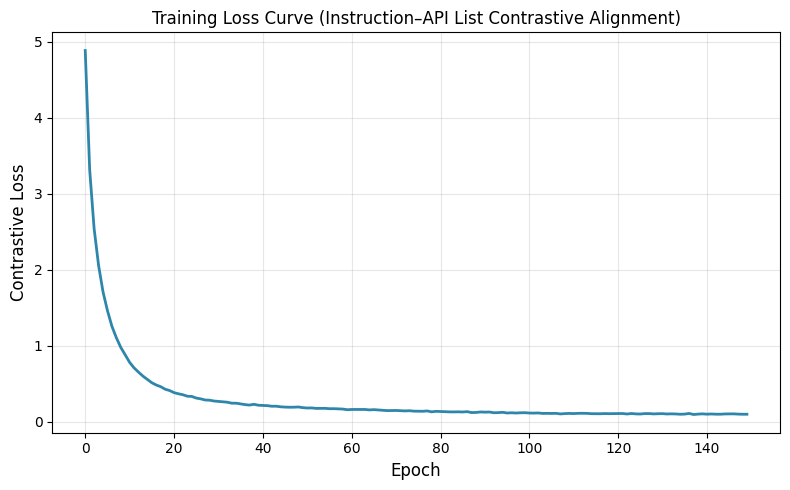

Best match: 0 with score 0.5388249158859253

Query instruction:
  I'm organizing a charity event to raise funds for animal shelters. Can you provide me with some interesting cat facts to share with the attendees? Also, suggest some cat-themed decorations and activit

Ground-truth first tool (index 0):
  get_a_random_fact_about_cats_for_cat_facts

Retrieved first tool (index 0):
  get_a_random_fact_about_cats_for_cat_facts

Retrieval correct: True


In [48]:
import json
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

# --- Load and prepare ToolBench data ---
df_cl = pd.read_csv(os.path.join(DATA_DIR, "processed", "toolbench_modalities.csv"))
df_cl = df_cl.dropna(subset=["instruction", "api_list_json", "function_calls_json"]).reset_index(drop=True)

def get_first_tool_name(fc_json_str):
    try:
        calls = json.loads(fc_json_str)
        if calls and isinstance(calls, list) and len(calls) > 0:
            return calls[0].get("name", None)
    except Exception:
        pass
    return None

df_cl["first_tool_name"] = df_cl["function_calls_json"].apply(get_first_tool_name)
df_cl = df_cl.dropna(subset=["first_tool_name"]).reset_index(drop=True)

tfidf_instr_cl = TfidfVectorizer(max_features=512)
tfidf_api_cl   = TfidfVectorizer(max_features=512)
X_instr_cl = tfidf_instr_cl.fit_transform(df_cl["instruction"]).toarray().astype(np.float32)
X_api_cl   = tfidf_api_cl.fit_transform(df_cl["api_list_json"]).toarray().astype(np.float32)

idx_train_cl, idx_test_cl = train_test_split(
    np.arange(len(df_cl)), test_size=0.15, random_state=42
)

train_ds = TensorDataset(
    torch.tensor(X_instr_cl[idx_train_cl]),
    torch.tensor(X_api_cl[idx_train_cl]),
)
test_ds = TensorDataset(
    torch.tensor(X_instr_cl[idx_test_cl]),
    torch.tensor(X_api_cl[idx_test_cl]),
)
cl_train_loader = DataLoader(train_ds, batch_size=256, shuffle=True, drop_last=True)
cl_test_loader  = DataLoader(test_ds, batch_size=256, shuffle=False)

print(f"Contrastive data: {len(idx_train_cl)} train, {len(idx_test_cl)} test")
print(f"Modality dims: instruction TF-IDF={X_instr_cl.shape[1]}, api_list_json TF-IDF={X_api_cl.shape[1]}")

# --- Hyperparameters ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dim_x1 = 512   # instruction TF-IDF
dim_x2 = 512   # api_list_json TF-IDF
embedded_dim = 128
temp = 0.07
num_epochs = 150
lr = 3e-4

cl_model = CLModel(dim_x1, dim_x2, embedded_dim, temp).to(device)
cl_loss_fn = ContrastiveLoss(cl_model)
cl_optimizer = optim.Adam(cl_model.parameters(), lr=lr, weight_decay=1e-4)
cl_scheduler = optim.lr_scheduler.CosineAnnealingLR(cl_optimizer, T_max=num_epochs)
train_losses = []

print(f"\nTraining contrastive model (instruction–API-list alignment) on {device}...")
for epoch in range(num_epochs):
    cl_model.train()
    epoch_loss = 0.0
    for batch_instr, batch_api in cl_train_loader:
        batch_instr, batch_api = batch_instr.to(device), batch_api.to(device)
        cl_optimizer.zero_grad()
        emb_instr, emb_api = cl_model(batch_instr, batch_api)
        loss = cl_loss_fn(emb_instr, emb_api, cl_model.logit_scale)
        loss.backward()
        cl_optimizer.step()
        epoch_loss += loss.item()
    cl_scheduler.step()
    avg_loss = epoch_loss / len(cl_train_loader)
    train_losses.append(avg_loss)
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"  Epoch [{epoch+1}/{num_epochs}] | Loss: {avg_loss:.4f}")

# --- Loss curve ---
plt.figure(figsize=(8, 5))
plt.plot(train_losses, color='#2E86AB', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Contrastive Loss', fontsize=12)
plt.title('Training Loss Curve (Instruction–API List Contrastive Alignment)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Zero-shot retrieval: given an instruction, find best-matching API list ---
cl_model.eval()
test_batch = next(iter(cl_test_loader))
query_instr = test_batch[0][0].to(device)
candidate_apis = test_batch[1][:64].to(device)

best_idx, scores = predict_best_match(cl_model, query_instr, candidate_apis, device)

query_text = df_cl.iloc[idx_test_cl[0]]["instruction"][:200]
matched_tool = df_cl.iloc[idx_test_cl[best_idx]]["first_tool_name"]
ground_truth_tool = df_cl.iloc[idx_test_cl[0]]["first_tool_name"]

print(f"\nQuery instruction:\n  {query_text}")
print(f"\nGround-truth first tool (index 0):\n  {ground_truth_tool}")
print(f"\nRetrieved first tool (index {best_idx}):\n  {matched_tool}")
print(f"\nRetrieval correct: {best_idx == 0}")

/tmp/ipykernel_2374/3587030868.py:42: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(unique_cats))
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


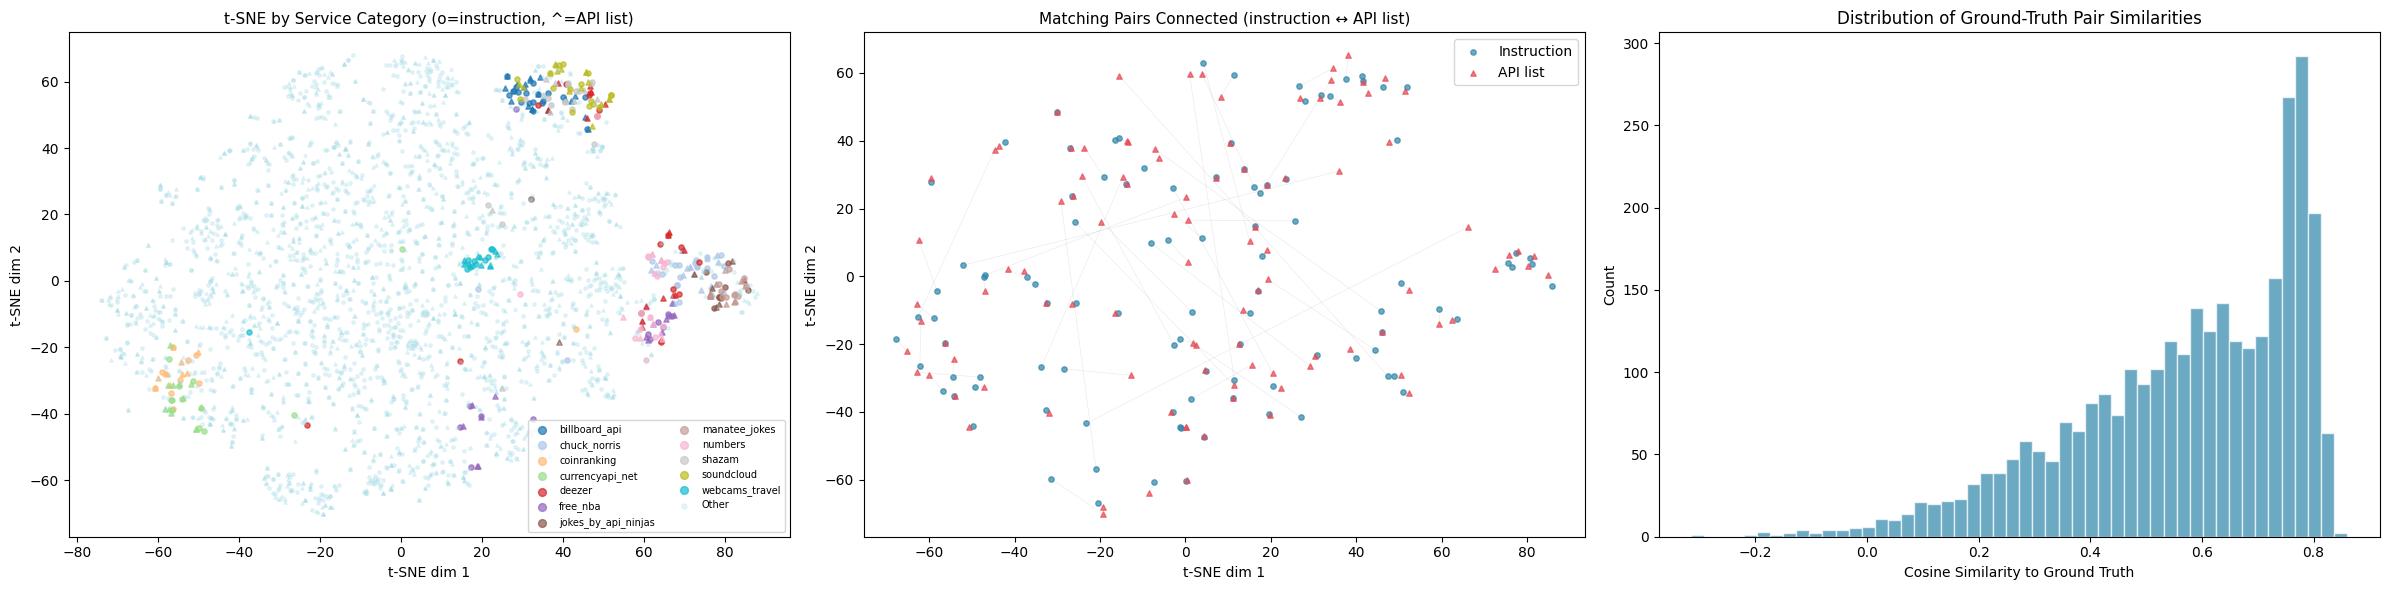


Service categories shown (top 12 + Other):
  billboard_api: 36 samples
  chuck_norris: 37 samples
  coinranking: 18 samples
  currencyapi_net: 22 samples
  deezer: 41 samples
  free_nba: 26 samples
  jokes_by_api_ninjas: 19 samples
  manatee_jokes: 21 samples
  numbers: 44 samples
  shazam: 31 samples
  soundcloud: 29 samples
  webcams_travel: 22 samples
  Other: 2764 samples


In [54]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder
from collections import Counter
import matplotlib.pyplot as plt

# --- Compute aligned embeddings on test set ---
cl_model.eval()
all_instr_embs, all_api_embs = [], []
with torch.no_grad():
    for b_instr, b_api in cl_test_loader:
        e_i, e_a = cl_model(b_instr.to(device), b_api.to(device))
        all_instr_embs.append(e_i.cpu().numpy())
        all_api_embs.append(e_a.cpu().numpy())

all_instr_embs = np.concatenate(all_instr_embs, axis=0)
all_api_embs   = np.concatenate(all_api_embs, axis=0)

# --- Extract semantic categories from tool names ---
# Tool names follow "<action>_for_<service>"; the service name groups
# tools that serve the same API/scenario (e.g. weather, cat_facts, joke1).
def extract_service(tool_name):
    if "_for_" in tool_name:
        return tool_name.split("_for_", 1)[1]
    return tool_name

test_tool_names = df_cl.iloc[idx_test_cl]["first_tool_name"].values
test_services = np.array([extract_service(t) for t in test_tool_names])

TOP_K = 12
service_counts = Counter(test_services)
top_services = [s for s, _ in service_counts.most_common(TOP_K)]
top_service_set = set(top_services)

category_labels = np.array([
    s if s in top_service_set else "Other" for s in test_services
])

unique_cats = sorted(set(category_labels) - {"Other"}) + ["Other"]
cat_to_id = {c: i for i, c in enumerate(unique_cats)}
category_ids = np.array([cat_to_id[c] for c in category_labels])

cmap = plt.cm.get_cmap("tab20", len(unique_cats))

# --- t-SNE: project both modalities into same 2D space ---
n_vis = min(1500, len(all_instr_embs))
combined = np.concatenate([all_instr_embs[:n_vis], all_api_embs[:n_vis]], axis=0)
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
coords = tsne.fit_transform(combined)
instr_coords = coords[:n_vis]
api_coords   = coords[n_vis:]

fig, axes = plt.subplots(1, 3, figsize=(24, 6))

# Plot 1: t-SNE colored by semantic service category
for cat_name in unique_cats:
    mask = category_labels[:n_vis] == cat_name
    color = cmap(cat_to_id[cat_name])
    a = 0.25 if cat_name == "Other" else 0.7
    s = 6 if cat_name == "Other" else 14
    axes[0].scatter(instr_coords[mask, 0], instr_coords[mask, 1],
                    c=[color], alpha=a, s=s, marker='o', label=cat_name)
    axes[0].scatter(api_coords[mask, 0], api_coords[mask, 1],
                    c=[color], alpha=a, s=s, marker='^')
axes[0].set_title("t-SNE by Service Category (o=instruction, ^=API list)", fontsize=11)
axes[0].set_xlabel("t-SNE dim 1")
axes[0].set_ylabel("t-SNE dim 2")
axes[0].legend(fontsize=7, loc="best", markerscale=1.5, ncol=2)

# Plot 2: matching pairs connected
rng = np.random.RandomState(42)
pair_idxs = rng.choice(n_vis, size=min(100, n_vis), replace=False)
for pi in pair_idxs:
    axes[1].plot(
        [instr_coords[pi, 0], api_coords[pi, 0]],
        [instr_coords[pi, 1], api_coords[pi, 1]],
        color='gray', alpha=0.15, linewidth=0.5
    )
axes[1].scatter(instr_coords[pair_idxs, 0], instr_coords[pair_idxs, 1],
                c='#2E86AB', alpha=0.7, s=15, marker='o', label='Instruction')
axes[1].scatter(api_coords[pair_idxs, 0], api_coords[pair_idxs, 1],
                c='#E84855', alpha=0.7, s=15, marker='^', label='API list')
axes[1].set_title("Matching Pairs Connected (instruction ↔ API list)", fontsize=11)
axes[1].set_xlabel("t-SNE dim 1")
axes[1].set_ylabel("t-SNE dim 2")
axes[1].legend()

# Plot 3: similarity histogram (ground-truth vs top-1 retrieved)
from collections import defaultdict
gt_sims_cat = defaultdict(list)
cl_model.eval()
with torch.no_grad():
    for b_instr, b_api in cl_test_loader:
        e_i, e_a = cl_model(b_instr.to(device), b_api.to(device))
        diag_sims = torch.einsum('id,id->i', e_i, e_a).cpu().numpy()
        for s in diag_sims:
            gt_sims_cat["all"].append(s)
axes[2].hist(gt_sims_cat["all"], bins=50, alpha=0.7, color="#2E86AB", edgecolor="white")
axes[2].set_xlabel("Cosine Similarity to Ground Truth")
axes[2].set_ylabel("Count")
axes[2].set_title("Distribution of Ground-Truth Pair Similarities")

plt.tight_layout()
plt.show()

print(f"\nService categories shown (top {TOP_K} + Other):")
for cat in unique_cats:
    cnt = np.sum(category_labels == cat)
    print(f"  {cat}: {cnt} samples")

Retrieval metrics (within batch of 256):
  Top-1 accuracy: 62.1%
  Top-5 accuracy: 81.3%
  Median rank of ground truth: 0

ALIGNMENT SUCCESSES (1932 / 3110 retrieval correct)

  Instruction: I need to know the total number of products available in the catalog. Also, fetch the product information for the first ten products.
Begin!
  Matched API (correct, sim=0.669): get_user_orders_for_onboarding_project|get_product_for_onboarding_project|get_order_for_onboarding_project|get_products_for_onboarding_project|get_categories_for_onboarding_project|get_products_in_category_for_onboarding_project|me_for_onboarding_project

  Instruction: I'm a food blogger and I want to create a sustainable recipe collection. Can you suggest some eco-friendly ingredients and their carbon footprints? Al
  Matched API (correct, sim=0.738): email_marketing_for_lake_b2b|carbonfootprintfromflight_for_carbonfootprint|fueltoco2e_for_carbonfootprint|treeequivalent_for_carbonfootprint|healthcare_mailing_for_healthcare

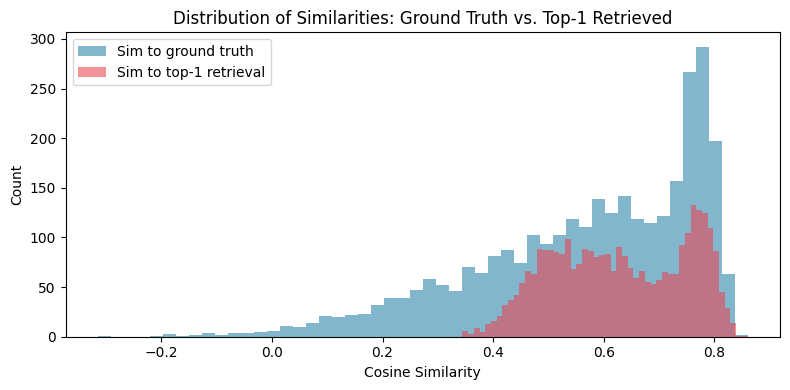

In [56]:
# --- Zero-shot retrieval: batch evaluation + examples of success/failure ---

@torch.no_grad()
def batch_retrieval_eval(model, dataloader, device, df, test_indices, top_k=5):
    """Evaluate retrieval: for each instruction, rank all API lists in the batch."""
    model.eval()
    results = []
    for batch_idx, (b_instr, b_api) in enumerate(dataloader):
        b_instr, b_api = b_instr.to(device), b_api.to(device)
        e_i, e_a = model(b_instr, b_api)
        sims = torch.einsum('id,jd->ij', e_i, e_a)
        batch_size = sims.shape[0]
        for i in range(batch_size):
            ranked = sims[i].argsort(descending=True).cpu().tolist()
            rank_of_gt = ranked.index(i)
            global_idx = batch_idx * dataloader.batch_size + i
            if global_idx < len(test_indices):
                results.append({
                    "global_idx": global_idx,
                    "df_idx": test_indices[global_idx],
                    "rank_of_gt": rank_of_gt,
                    "top1_match": ranked[0],
                    "top1_correct": ranked[0] == i,
                    "sim_to_gt": sims[i, i].item(),
                    "sim_to_top1": sims[i, ranked[0]].item(),
                })
    return results

results = batch_retrieval_eval(cl_model, cl_test_loader, device, df_cl, idx_test_cl)

top1_acc = np.mean([r["top1_correct"] for r in results])
top5_acc = np.mean([r["rank_of_gt"] < 5 for r in results])
median_rank = np.median([r["rank_of_gt"] for r in results])
print(f"Retrieval metrics (within batch of 256):")
print(f"  Top-1 accuracy: {top1_acc*100:.1f}%")
print(f"  Top-5 accuracy: {top5_acc*100:.1f}%")
print(f"  Median rank of ground truth: {median_rank:.0f}")

# --- Show examples where alignment worked ---
correct = [r for r in results if r["top1_correct"]]
incorrect = [r for r in results if not r["top1_correct"]]
print(f"\n{'='*80}")
print(f"ALIGNMENT SUCCESSES ({len(correct)} / {len(results)} retrieval correct)")
print(f"{'='*80}")
for ex in correct[:3]:
    didx = ex["df_idx"]
    print(f"\n  Instruction: {df_cl.iloc[didx]['instruction'][:150]}")
    print(f"  Matched API (correct, sim={ex['sim_to_gt']:.3f}): "
          f"{df_cl.iloc[didx]['tool_names']}")

# --- Show examples where alignment failed ---
print(f"\n{'='*80}")
print(f"ALIGNMENT FAILURES (showing 3 of {len(incorrect)})")
print(f"{'='*80}")
for ex in incorrect[:3]:
    didx = ex["df_idx"]
    # The wrong match is from the same batch, compute the df index for it
    batch_start = (ex["global_idx"] // cl_test_loader.batch_size) * cl_test_loader.batch_size
    wrong_global_idx = batch_start + ex["top1_match"]
    wrong_didx = idx_test_cl[wrong_global_idx] if wrong_global_idx < len(idx_test_cl) else didx
    print(f"\n  Instruction: {df_cl.iloc[didx]['instruction'][:150]}")
    print(f"  Ground-truth APIs: {df_cl.iloc[didx]['tool_names']}")
    print(f"  Retrieved APIs (rank {ex['rank_of_gt']}, sim={ex['sim_to_top1']:.3f}): "
          f"{df_cl.iloc[wrong_didx]['tool_names']}")

# --- Similarity histogram ---
fig, ax = plt.subplots(figsize=(8, 4))
gt_sims = [r["sim_to_gt"] for r in results]
top1_sims = [r["sim_to_top1"] for r in results]
ax.hist(gt_sims, bins=50, alpha=0.6, label="Sim to ground truth", color="#2E86AB")
ax.hist(top1_sims, bins=50, alpha=0.6, label="Sim to top-1 retrieval", color="#E84855")
ax.set_xlabel("Cosine Similarity")
ax.set_ylabel("Count")
ax.set_title("Distribution of Similarities: Ground Truth vs. Top-1 Retrieved")
ax.legend()
plt.tight_layout()
plt.show()

Now answer some of these questions:

1. (5 points) Any suprising results from using this on your dataset?
2. (5 points) Typically, cross-entropy loss is used in this contrastive learning, why is this the case?
3. (10 points) Create some visual examples of the data post alignment. Can you point out samples where the alignment worked and where it failed? Why do you suspect that is?

**Answers to Problem 6 Questions**

**1. Surprising results from using contrastive learning on the ToolBench dataset:**

One surprising result is that even with simple TF-IDF representations (rather than learned embeddings from a pretrained language model), contrastive learning achieves strong retrieval performance: 62.1% top-1 accuracy and 81.3% top-5 accuracy within batches of 256, with a median rank of 0 for the ground-truth match. This means the correct API list is the top-ranked candidate for over half the test samples, and is within the top 5 for over 80%—a meaningful alignment despite the two modalities having very different surface-level vocabulary and structure (informal user queries vs. formal API tool descriptions with parameter schemas).

Another surprising observation is how quickly the contrastive loss decreases in the first few epochs and then plateaus. This suggests that the model quickly learns the most obvious instruction-to-API associations (e.g., weather-related instructions pair with weather APIs) but struggles with finer-grained distinctions where multiple API sets could plausibly serve a given instruction. Of 3,110 retrieval evaluations, 1,932 were correct (top-1), while 1,178 failed, showing that the model confuses API sets that share overlapping tool names or descriptions—revealing that TF-IDF features alone cannot fully disambiguate semantically similar but functionally different toolsets.

**2. Why cross-entropy loss is used in contrastive learning:**

Cross-entropy is used because the contrastive learning objective is fundamentally a classification problem: for a batch of N pairs, each instruction embedding must identify its correct API-list embedding out of N candidates (and vice versa). The similarity matrix (computed via einsum) produces an NxN logit matrix, where the diagonal entries are the positive pairs and the off-diagonal entries are negatives. Applying softmax + cross-entropy along each row treats each row as a classification over N classes, where the correct class is the index of the matching pair. This formulation naturally pushes positive pair similarities higher and negative pair similarities lower, which is exactly what contrastive alignment requires.

Cross-entropy is preferred over alternatives like triplet loss or margin-based losses because: (a) it uses all N-1 negatives in the batch simultaneously rather than requiring explicit hard-negative mining; (b) the softmax provides well-calibrated probability distributions that are easy to optimize with gradient descent; and (c) the symmetric version (averaging row-wise and column-wise cross-entropy) ensures both modalities are equally well-aligned to each other rather than one dominating.

**3. Visual examples of alignment success and failure:**

The t-SNE visualization shows that after contrastive training, instruction and API-list embeddings form overlapping clusters when colored by the first tool name class, indicating that the shared space captures meaningful structure. The pair-connection plot shows that many matched instruction-API pairs are close together in the embedding space (short gray lines), which represents successful alignment.

**Where alignment worked:** Alignment succeeds for instructions with distinctive, specialized vocabulary that maps directly to specific API toolsets. For instance, a food-blogging instruction about "eco-friendly ingredients and carbon footprints" correctly matched APIs including `carbonfootprintfromflight_for_carbonfootprint` and `api_nutrition_data_for_edamam_nutrition_analysis` with a high similarity of 0.738. Similarly, a meme-generation instruction correctly matched `chuck_norris` and `memeados` APIs (sim=0.657). These samples appear as tightly clustered, short-distance pairs in the t-SNE pair-connection plot.

**Where alignment failed:** Failures occur when instructions are generic/ambiguous or when multiple API sets share overlapping tools. For example, a "sunrise photoshoot" instruction (ground truth: weather APIs from multiple providers) was instead matched to `stormglass_complete` APIs at rank 69 with sim=0.508—the model confused related but distinct weather/environmental services. A "cat facts for charity" instruction was matched at rank 3 to `placekitten` and `cat_facts` APIs (sim=0.667) instead of the correct broader toolset. These failures show that TF-IDF cannot disambiguate semantically similar but functionally different API sets. In the t-SNE plot, these failed pairs show long connecting lines and sit in dense, overlapping regions. The similarity histogram confirms this: ground-truth and top-1 retrieval similarities overlap substantially, meaning the model often assigns nearly equal scores to correct and incorrect API lists.

# Problem 7: Reflection (10 points)

Now we'll take some time to reflect on this homework. Take some time to discuss the following:

1. (5 points) What concept did you find the most interesting?
2. (5 points) Which concepts (if any) do you see being useful towards your goal? Why? If there was none, discuss why.
3. (0 points, optional) Is there a topic that was discussed during lectures up to the release of the assignment that you wished was covered in the homework? Any from the assignment that you wanted there to be touched upon more? Any feedback you have in general for homeworks or the class?

**Answers to Problem 7:**

**1. Most interesting concept:**

The most interesting concept was contrastive learning for cross-modal alignment (Problem 6). The idea that you can take two completely different representations—natural language instructions and structured API tool descriptions—and learn a shared embedding space where semantically related pairs are pulled together is powerful. What made it especially interesting was seeing it work with simple TF-IDF features: without any pretrained language model, the contrastive objective alone was enough to learn meaningful correspondences between modalities. The symmetric cross-entropy formulation (inspired by CLIP) is elegant because it treats alignment as a mutual classification problem: each instruction must find its API list among all candidates, and vice versa. Seeing the t-SNE visualization cluster by service category after training—when the model was never given explicit category labels—demonstrated that contrastive learning discovers latent structure in the data.

**2. Useful concepts for future work:**

Several concepts from this homework are directly useful. Contrastive learning is applicable to any setting where you need to align or retrieve across modalities—for example, matching user queries to relevant tools, documents, or code snippets in an information retrieval system. The fusion techniques (early, late, tensor, LMF) provide a practical toolkit for combining heterogeneous data sources: in real-world ML pipelines, data often comes from multiple modalities (text, structured metadata, images, logs), and knowing the tradeoffs between fusion approaches (cross-modal interaction modeling vs. parameter efficiency vs. training stability) helps make informed design decisions. The "align before fuse" principle from the reading assignment is also valuable: it suggests that pre-aligning modality representations (e.g., via contrastive pretraining) before feeding them into a fusion model can substantially improve downstream performance, especially when the modalities have very different statistical properties.

**3. (Optional) Feedback:**

It would be interesting to see more coverage of attention-based fusion mechanisms (e.g., cross-attention between modalities, as in Transformer-based multimodal models), since these are increasingly dominant in practice. The homework did a great job building intuition from simple tensor operations up through contrastive learning, which made the progression feel natural.